## Trabalho 2 — INF-0618 Deep Learning   
Alunos:
- Vitor de Oliveira Fernandez Araujo
- Vitor Sancho Cardoso


Neste trabalho, vamos utilizar o conjunto de dados Measuring Hate Speech (Medindo discurso de ódio). Este conjunto de dados foi criado e publicado por Kennedy et al. (2020) e Sachdeva et al. (2022). Os dados coletados são de 3 diferentes redes sociais: Twitter (tweets), Youtube (comentários de vídeos) e Reddit (comentários em posts), entre Março e Agosto de 2019, apenas na lingua inglesa.

O principal rótulo do dataset consiste em "hate speech score", um score de quanto a amostra representa discurso de ódio. Esse score foi construído a partir de outras 10 categorias de discurso de ódio (sentimento, respeito, insulto, humilhação, status, violência, desumanização, genocídio, ataque/defesa, discurso de ódio). Cada amostra foi classificada por diferentes anotadores (ao total 8,472 anotadores). Outras informações como grupos alvo e subgrupos, assim como a demografia dos anotadores, também existem no dataset.
Para uma análise e entendimento melhor da teoria por trás da forma de coleta, recomenda-se o paper "The Measuring Hate Speech Corpus: Leveraging Rasch Measurement Theory for Data Perspectivism".

Para esse trabalho específico, utilizaremos uma versão deste conjunto de dados onde o resultado de "hate speech score" dos diferentes anotadores de cada amostra foram utilizados para construir um score médio, simplificando o problema (ignorando o viés dos anotadores). Desta forma, nosso problema é um problema de **regressão**. Além disso, utilizaremos menos amostras, apenas 27695.

O dataset completo pode ser acessado no link do [hugging face](https://huggingface.co/datasets/ucberkeley-dlab/measuring-hate-speech), enquanto o **dataset que deve ser usado** esta na [mesma pasta compartilhada do trabalho 1 (aqui)](https://drive.google.com/drive/folders/1OYDEVPH52LF0Z4hg5uq3LnvsWB61_5zA?usp=sharing), na pasta "hate_speech_ds".




## Instalação das Bibliotecas

Para instalar as bibliotecas necessárias, execute os comandos abaixo:

In [1]:
# Já instalados no colab, instalar localmente!
# !pip install pandas
# !pip install transformers

# Não instalado no Colab
!pip install bertviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 139.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 9.3 MB/s eta 0:00:00


## Carregar e preparar os dados

O conjunto de dados já vem pré dividido, consistindo nas seguintes colunas:

- **comment_id**: O id da amostra;
- **text**: O conteúdo textual da amostra, retirado do twitter, reddit ou youtube;
- **hate_speech_score**: Um score em ponto flutuante (float) de quanto a amostra se alinha a discurso de ódio (mais positivo), ou a discursos benéficos/não odiosos (negativo).


In [2]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np

# Usa uma seed global para o TensorFlow, para resultados reprodutíveis
tf.random.set_seed(42)

In [3]:
import os

PATH = '/tmp/hf_cache'
os.environ['TRANSFORMERS_CACHE'] = PATH
os.environ['HF_HOME'] = PATH
os.environ['HF_DATASETS_CACHE'] = PATH
os.environ['TORCH_HOME'] = PATH

In [4]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
colab_path = "/content/drive/MyDrive/MDC_Datasets/"

In [6]:
from datasets import load_from_disk

ds = load_from_disk(colab_path + "/measuring_hate_speech_custom.hf")
ds

DatasetDict({
    train: Dataset({
        features: ['comment_id', 'text', 'hate_speech_score'],
        num_rows: 11869
    })
    validation: Dataset({
        features: ['comment_id', 'text', 'hate_speech_score'],
        num_rows: 7913
    })
    test: Dataset({
        features: ['comment_id', 'text', 'hate_speech_score'],
        num_rows: 7913
    })
})

In [7]:
# Separa os dados
df_train = ds['train']
df_val = ds['validation']
df_test = ds['test']
del ds # limpa memoria

df_train.shape[0], df_val.shape[0], df_test.shape[0],

(11869, 7913, 7913)

O rótulo do nosso dataset, hate_speech_score, possui um range alto tanto de valores positivos quanto negativos. Isso pode impactar a performance do modelo, portanto precisamos normalizar essa variável antes do treinamento.

In [8]:
print(f'Maior valor de treino: {max([x for x in df_train['hate_speech_score']]):.3f}, e menor valor de treino: {min([x for x in df_train['hate_speech_score']]):.3f}')

Maior valor de treino: 6.300, e menor valor de treino: -8.340


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Transforma em 2D (formato esperado do sklearn scaler)
train_labels = np.array(df_train['hate_speech_score']).reshape(-1, 1)
scaler.fit(train_labels)

# Cria uma função com o scaler para usar o 'map' do Hugging Face
def scale_labels(examples):
  scaled_score = scaler.transform(np.array(examples['hate_speech_score']).reshape(-1, 1))
  # Após o flatten ainda sobra uma dimensão que tem apenas um valor/rótulo
  return {'hate_speech_score': scaled_score.flatten()[0]}

df_train = df_train.map(scale_labels)
df_val = df_val.map(scale_labels)
df_test = df_test.map(scale_labels)

## Exibir uma amostra alta e outra baixa

Este código pega uma amostra com rótulo negativo e outra bem positivo como exemplos


In [10]:
import random
from datasets import Dataset
import datasets
# Tira a barra de progresso momentaneamente
# datasets.disable_progress_bars()

# Coleta uma amostra baixa e outra alta
low_samples = []
high_samples = []
for sample in df_train:
  if sample['hate_speech_score'] < 0.05: # lembrando que esta normalizado entre 0 e 1
    low_samples.append(sample)
  elif sample['hate_speech_score'] > 0.95:
    high_samples.append(sample)

  if len(high_samples) > 0 and len(low_samples)>0:
    break

# Mostra as amostras
print(f'Sample com discurso de ódio\nTexto: {high_samples[0]['text']}\nRótulo: {high_samples[0]['hate_speech_score']}')
print("\n")
print(f'Sample sem discurso de ódio\nTexto: {low_samples[0]['text']}\nRótulo: {low_samples[0]['hate_speech_score']}')

Sample com discurso de ódio
Texto: Dig burn PITS and treat them THE INVADING NAZIS ALL OVER EUROPE. ESPECIALLY THE WOMEN DON'T LET THEM BREED HERE MR. PRESIDENT. FIRING SQUADS SO I CAN VOLUNTEER
Rótulo: 1.0


Sample sem discurso de ódio
Texto: Fellow trans girl here! Love and support confirmed!
Rótulo: 0.0


## Exemplo: Carregar modelo e tokenizer BERT para classificação

Neste exemplo, utilizamos a biblioteca `transformers` para carregar um modelo BERT pré-treinado e o tokenizer correspondente, configurado para uma tarefa de classificação binária. O número de classes é definido como 1, de forma que a função de carregamento entende que é um problema de regressão.

Você pode ajustar o modelo de acordo com sua capacidade computacional. Aqui estão as opções de modelos disponíveis:
- **"prajjwal1/bert-tiny" (~4M)**: Modelo mais leve, ideal para recursos limitados.
- **"prajjwal1/bert-small" (~28M)**: Um pouco maior, ainda eficiente para muitos cenários.
- **"prajjwal1/bert-medium" (~41M)**: Modelo médio, reduzido em mais da metade do tamanho original do BERT.
- **"bert-base-uncased" (~110M)**: Modelo padrão e mais pesado, adequado para máquinas mais potentes (Esse é demorado de rodar no Colab, e precisa de batch size pequeno).

In [41]:
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

NUM_LABELS = 1
model_name = "prajjwal1/bert-small" # Escolha o modelo conforme sua necessidade
baseline_tokenizer = AutoTokenizer.from_pretrained(model_name)  # Carregar o tokenizer
baseline_model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_LABELS, from_pt=True)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [12]:
baseline_model.summary()

Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  28763648  
                                                                 
 dropout_13 (Dropout)        multiple                  0         
                                                                 
 classifier (Dense)          multiple                  513       
                                                                 
Total params: 28764161 (109.73 MB)
Trainable params: 28764161 (109.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Funções auxiliares

In [75]:
def plot_loss(history):
  history_dict = history.history

  plt.figure(figsize=(14, 5))

  plt.subplot(1, 2, 1)
  plt.plot(history_dict['loss'], label='Training Loss')
  if 'val_loss' in history_dict:
      plt.plot(history_dict['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss over Epochs')
  plt.legend()

  plt.tight_layout()
  plt.show()

## Atividade

Para o desenvolvimento deste trabalho, siga atentamente as atividades listadas a seguir. Em cada uma delas, espera-se que você apresente uma descrição detalhada dos experimentos realizados, acompanhada de uma discussão aprofundada dos resultados obtidos. Cada atividade possui uma pontuação específica, que será atribuída de acordo com a execução e a qualidade da análise apresentada.

Lembre-se de que a clareza na explicação dos métodos e a precisão na interpretação dos dados são essenciais para a avaliação. Bons resultados são importantes, mas a capacidade de refletir criticamente sobre eles é o ponto principal da tarefa.

Nota Importante: O conjunto de teste deve ser utilizado apenas uma vez, no final de todas as experimentações!

 ### Construção do conjunto de dados

 1. (1.0) O código abaixo utiliza o tokenizador carregado na variável `tokenizer` para processar os dados para o Transformer. Na função existe uma lacuna definindo o tamanho máximo dos dados processados (`max_length`). Estude a distribuição dos dados de treino do conjunto, escolha um `max_length` adequado e discuta o valor decidido. Lembre-se que o número de tokens não é a mesma coisa que o número de palavras do texto (algumas palavras são quebradas em múltiplos tokens, assim como pontuações). Uma boa forma de analisar tal distribuição é com histogramas ou gráficos similares. Escolha um modelo dos citados anteriormente como *Baseline*.

 - Note que, sempre que um novo modelo for carregado, o pré processamento declarado aqui deve ser *re-executado*, tendo em vista a diferença entre os tokenizadores.

- Nesta seção que o **batch_size** é definido. Preste atenção a este valor, valores maiores aceleram o tempo de treino dos modelos, porém utilizam mais memória. É preciso encontrar o equilíbrio de acordo com a máquina disponível para cada modelo executado.*





</br>
*O uso de um batch size muito diferente tem impacto no resultado dos modelos, porém neste trabalho isso não será avaliado negativamente, pois o foco é utilizar o máximo possível da GPU disponível. Caso tenham disponibilidade de hardware e tempo, utilizem o mesmo batch size entre os diferentes modelos (para serem melhor comparados).

### Escolha do `max_length` ideal

#### Discussão:

Como identificado no histograma abaixo, praticamente todos os textos têm menos de 150 tokens, então inicialmente decidimos seguir com este valor de max_length. No entanto, isso se mostrou muito desafiador para os recursos de memória disponíveis, já que a complexidade do treinamento escala de forma quadrática com o tamanho da sequência. Por este motivo, fizemos mais alguns testes e chegamos à conclusão de fazer o corte em 75 tokens, já que o conjunto de dados apresenta uma queda mais expressiva na quantidade de exemplos, a partir deste ponto.

Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

<Axes: ylabel='Count'>

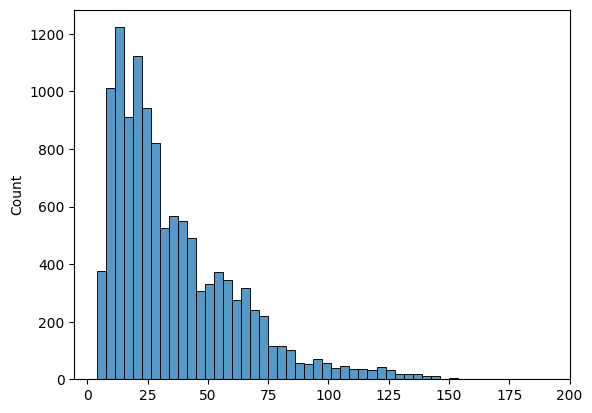

In [43]:
def tokenizer_test(batch):
  tokenized = baseline_tokenizer(
        batch['text'],
        truncation=False
    )

  # Coloca os rótulos no resultado
  tokenized['length'] = [len(tk) for tk in tokenized['input_ids']]

  return tokenized


tokenized_train = df_train.map(
    tokenizer_test,
    batched=True,
    remove_columns=['comment_id'],
    keep_in_memory=True
)

sns.histplot(tokenized_train['length'], bins=50)

In [61]:
TOKEN_MAX_LENGTH = 75
BATCH_SIZE = 32

def tokenize_datasets(tokenizer,
                      datasets_dict,
                      batch_size=BATCH_SIZE,
                      token_max_length=TOKEN_MAX_LENGTH):

  def preprocess_function(samples):
      """
      Processa o dataset, tokenizando os textos.
      Também retorna os rótulos para construção dos batches.
      """

      # "Tokeniza" os textos
      tokenized = tokenizer(
          samples['text'],
          truncation=True,
          padding='max_length',
          max_length=token_max_length
      )

      # Coloca os rótulos no resultado
      tokenized['labels'] = samples['hate_speech_score']

      return tokenized

  for type, dataset in datasets_dict.items():
    shuffle = True if type == 'train' else False

    yield dataset.map(
        preprocess_function,
        batched=True,
        keep_in_memory=True #evitar problemas com cache
      ).to_tf_dataset( # Configura os datasets para o padrão que o transformer espera (ids dos tokens e máscaras de atenção)
        columns=['input_ids', 'attention_mask'],
        label_cols='labels',
        batch_size=batch_size,
        shuffle=shuffle
      )

In [62]:
dataset_train, dataset_val, dataset_test = tokenize_datasets(
    baseline_tokenizer,
    {'train': df_train, 'val': df_val, 'test': df_test}
)

Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

### Cálculo de métricas no Conjunto de Validação (Baseline)

2.  (1.0) Baseado no modelo selecionado na atividade anterior, sem ajustes adicionais, calcule as métricas de Mean Absolute Error (Erro médio absoluto) - MAE, e Mean Squared Error (Erro quadrático médio) - MSE. Crie uma função que retorne os dois valores (como tupla, dicionário, ou de qualquer outra forma).


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def get_model_metrics(model, val_dataset=dataset_val):
  preds = model.predict(val_dataset)

  y_pred = preds.logits.squeeze()
  y_true = []

  for features, labels in val_dataset:
    y_true.extend(labels.numpy())

  y_true = np.array(y_true)

  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)

  return {'mae': mae, 'mse': mse}

In [53]:
baseline_metrics = get_model_metrics(baseline_model)
print(f"MAE Baseline: {baseline_metrics['mae']:.3f}")
print(f"MSE Baseline: {baseline_metrics['mse']:.3f}")

248/248 [==============================] - 4s 11ms/step
MAE Baseline: 0.795
MSE Baseline: 0.688


### Ajuste Fino (Fine-Tuning) de Modelos

3. (4.0) Efetue o ajuste fino (fine tuning) em **dois** modelos da lista apresentada no exemplo e compare-os. De preferência, teste um dos modelos mais leves (`tiny` ou `small`), e um dos mais pesados (`medium` ou `bert-base-uncased`). Caso o tempo de GPU seja um problema, é possível utilizar os dois menores apenas.</br>
- Para cada um dos modelos, experimente duas taxas de aprendizado: 0.01 e 0.00001 (embora outras taxas também possam ser exploradas). </br>
- Quais as métricas alcançadas no conjunto de validação para cada uma dessas taxas e em cada modelo? </br>
- Analise e debata as variações de desempenho observadas entre os modelos e as taxas.

In [77]:
from transformers import create_optimizer

EPOCHS = 5

def model_fit(model, lr, train_ds, val_ds, epochs=EPOCHS):
  model.layers[0].trainable = True

  total_steps = int(len(train_ds)*epochs)

  optimizer, schedule = create_optimizer(
      init_lr=lr,
      num_warmup_steps=int(0.1*total_steps),
      num_train_steps=total_steps,
      weight_decay_rate=0.01
  )

  model.compile(
      optimizer=optimizer,
      loss='mse',
      metrics=['mae']
  )

  return model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=epochs
  )

In [78]:
model_name_light = "prajjwal1/bert-small" # Escolha o modelo conforme sua necessidade
tokenizer_light = AutoTokenizer.from_pretrained(model_name_light)  # Carregar o tokenizer

dataset_train, dataset_val, dataset_test = tokenize_datasets(
    tokenizer_light,
    {'train': df_train, 'val': df_val, 'test': df_test},
    token_max_length=TOKEN_MAX_LENGTH,
    batch_size=BATCH_SIZE
)

model_light = TFAutoModelForSequenceClassification.from_pretrained(model_name_light, num_labels=1, from_pt=True, output_attentions=False)

h1 = model_fit(model_light, 1e-2, dataset_train, dataset_val)

model_light = TFAutoModelForSequenceClassification.from_pretrained(model_name_light, num_labels=1, from_pt=True, output_attentions=False)

h2 = model_fit(model_light, 1e-5, dataset_train, dataset_val)


Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 24s 50ms/step - loss: 0.0833 - mae: 0.2106 - val_loss: 0.0466 - val_mae: 0.1858
Epoch 2/5
371/371 [==============================] - 18s 48ms/step - loss: 0.0438 - mae: 0.1668 - val_loss: 0.0214 - val_mae: 0.1208
Epoch 3/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0303 - mae: 0.1389 - val_loss: 0.0313 - val_mae: 0.1364
Epoch 4/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0269 - mae: 0.1311 - val_loss: 0.0203 - val_mae: 0.1164
Epoch 5/5
371/371 [==============================] - 17s 47ms/step - loss: 0.0224 - mae: 0.1206 - val_loss: 0.0201 - val_mae: 0.1149


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 25s 50ms/step - loss: 0.0494 - mae: 0.1649 - val_loss: 0.0131 - val_mae: 0.0893
Epoch 2/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0196 - mae: 0.1116 - val_loss: 0.0112 - val_mae: 0.0825
Epoch 3/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0179 - mae: 0.1066 - val_loss: 0.0107 - val_mae: 0.0803
Epoch 4/5
371/371 [==============================] - 17s 47ms/step - loss: 0.0169 - mae: 0.1032 - val_loss: 0.0100 - val_mae: 0.0778
Epoch 5/5
371/371 [==============================] - 18s 47ms/step - loss: 0.0165 - mae: 0.1015 - val_loss: 0.0100 - val_mae: 0.0777


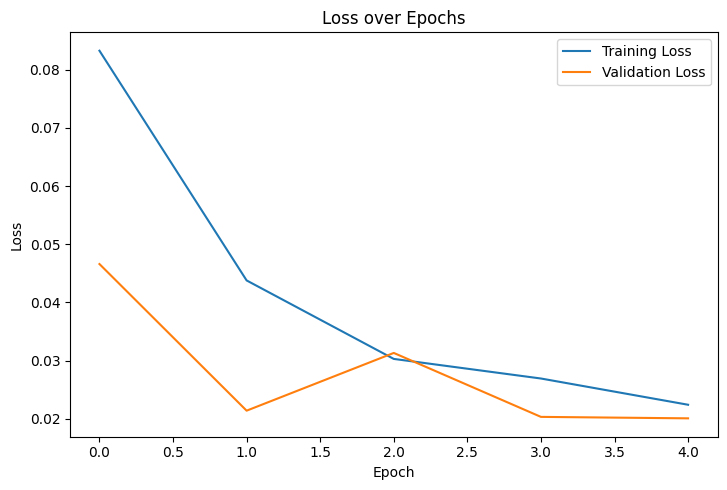

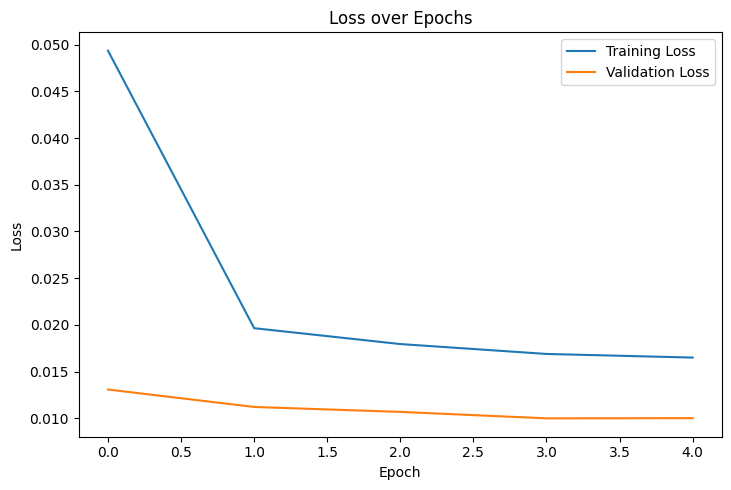

In [79]:
plot_loss(h1)
plot_loss(h2)

In [80]:
model_name_heavy = "prajjwal1/bert-medium" # Escolha o modelo conforme sua necessidade
tokenizer_heavy = AutoTokenizer.from_pretrained(model_name_heavy)  # Carregar o tokenizer

dataset_train, dataset_val, dataset_test = tokenize_datasets(
    tokenizer_heavy,
    {'train': df_train, 'val': df_val, 'test': df_test},
    token_max_length=TOKEN_MAX_LENGTH,
    batch_size=BATCH_SIZE
)

model_heavy = TFAutoModelForSequenceClassification.from_pretrained(model_name_heavy, num_labels=1, from_pt=True, output_attentions=False)

h1 = model_fit(model_heavy, 1e-2, dataset_train, dataset_val)

model_heavy = TFAutoModelForSequenceClassification.from_pretrained(model_name_heavy, num_labels=1, from_pt=True, output_attentions=False)

h2 = model_fit(model_heavy, 1e-5, dataset_train, dataset_val)

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/11869 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

Map:   0%|          | 0/7913 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/167M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 42s 86ms/step - loss: 0.1703 - mae: 0.2564 - val_loss: 0.0508 - val_mae: 0.1839
Epoch 2/5
371/371 [==============================] - 30s 81ms/step - loss: 0.0786 - mae: 0.2169 - val_loss: 0.0308 - val_mae: 0.1351
Epoch 3/5
371/371 [==============================] - 30s 81ms/step - loss: 0.0289 - mae: 0.1362 - val_loss: 0.0201 - val_mae: 0.1152
Epoch 4/5
371/371 [==============================] - 30s 80ms/step - loss: 0.0257 - mae: 0.1285 - val_loss: 0.0205 - val_mae: 0.1130
Epoch 5/5
371/371 [==============================] - 30s 81ms/step - loss: 0.0221 - mae: 0.1198 - val_loss: 0.0201 - val_mae: 0.1153


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
371/371 [==============================] - 43s 86ms/step - loss: 0.0337 - mae: 0.1388 - val_loss: 0.0111 - val_mae: 0.0821
Epoch 2/5
371/371 [==============================] - 30s 81ms/step - loss: 0.0164 - mae: 0.1011 - val_loss: 0.0098 - val_mae: 0.0769
Epoch 3/5
371/371 [==============================] - 30s 81ms/step - loss: 0.0138 - mae: 0.0928 - val_loss: 0.0094 - val_mae: 0.0752
Epoch 4/5
371/371 [==============================] - 30s 81ms/step - loss: 0.0125 - mae: 0.0885 - val_loss: 0.0094 - val_mae: 0.0753
Epoch 5/5
371/371 [==============================] - 30s 81ms/step - loss: 0.0119 - mae: 0.0864 - val_loss: 0.0092 - val_mae: 0.0744


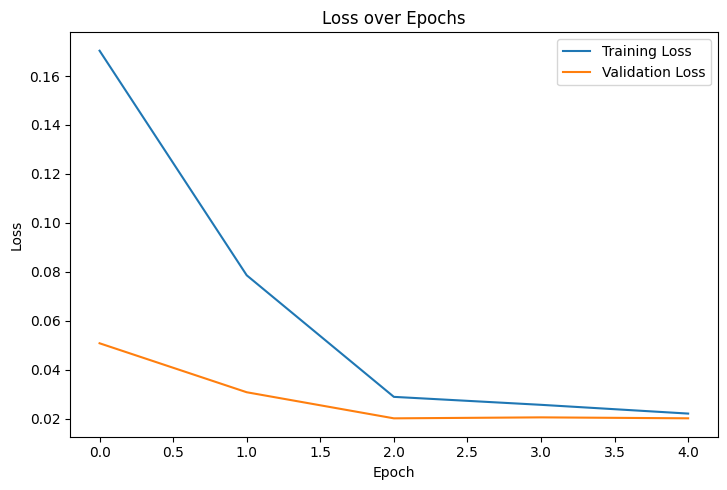

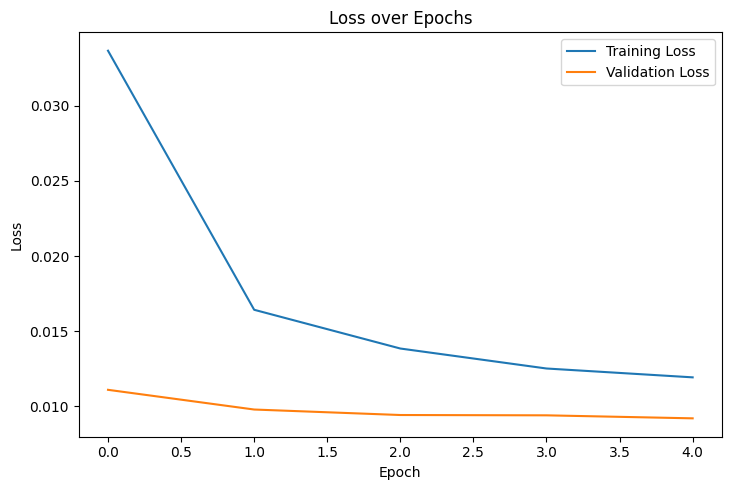

In [81]:
plot_loss(h1)
plot_loss(h2)

Discussão:
Testamos um total de 4 cenários. Avaliamos os modelos bert-medium e o bert-small, cada um com taxa de aprendizado de 1e-2 e 1e-5. Em todos não observamos indícios de overfitting para os modelos. No treinamento do bert-small com taxa de aprendizado de 1e-2, observamos um salto na Loss de validação para 2 épocas de trainamento, o que nos chamou atenção. Porém esse valor voltou ao comportamento esperado para as épocas seguintes, o que afastou a nossa preocupação de overfitting para essa configuração de treinamento.

Comparando as diferentes taxas de aprendizado, tanto o medium quanto o small obtiveram melhor performance com o valor de 1e-5 em comparação com o valor de 1e-2.
Ao comparar o medium e o small com taxa de aprendizado de 1e-5, podemos observar que o medium possui melhor performance. Porém, ao analisar no detalhe o valor de Loss em cada uma dessas configurações de modelos, vemos que na época 5 do modelo medium tivemos uma loss de 0.0092, enquanto no tiny tivemos 0.0100, uma diferença muito pequena entre os modelos. Ao comparar o tempo de treinamento de cada época, vemos que o tiny levou por volta de 18 segundos nas épocas finais de treinamento, enquanto o medium precisou de 30 segundos. Além disso, vale pontuar que o tiny requer menos recursos computacionais do que o medium.

Levando em consideração a performance equivalente entre o medium e o tiny, o melhor tempo de execução e o menor requisito computacional, podemos concluir que o tiny teve melhor desempenho que o medium.

### Avaliação do Modelo com Melhor Desempenho no Conjunto de teste
4. (2.0) Utilize o modelo com melhor desempenho no conjunto de teste e analise os resultados. Discuta brevemente os principais desafios enfrentados durante o treinamento do modelo e as soluções adotadas para superá-los. Além disso, reveja os hiperparâmetros escolhidos e reflita sobre o impacto potencial deles no desempenho do modelo.

In [82]:
# Adicione quantas células desejar!

Discussão:

### Análise do Mecanismo de Atenção com BertViz
5. (2.0) Use a ferramenta BertViz (github.com/jessevig/bertviz) para explorar os pesos do modelo selecionado na atividade anterior. Ao inspecionar o comportamento desse modelo, especificamente o transformador e seu mecanismo de atenção, quais padrões se tornam evidentes? Realize uma análise crítica desses padrões, destacando como eles podem impactar a interpretação e a performance do modelo.


In [83]:
# Adicione quantas células desejar!

Discussão: